In [2]:
from src.model.model import load_data, build_player_lookup, prepare_features, train_model, plot_feature_importance, plot_evaluation, save_model, predict_by_name
import pandas as pd

In [3]:
lineups, players = load_data()

player_lookup    = build_player_lookup(players)
archetype_lookup = dict(zip(players['PLAYER_ID'], players['cluster'].fillna(-1).astype(int)))
name_to_id       = dict(zip(players['PLAYER_NAME'], players['PLAYER_ID'].astype(str)))

df_features = prepare_features(lineups, player_lookup)

Loading data...
  7920 lineups  |  549 players

Engineering features...
  7920 lineups after filtering  |  22 features


In [65]:
lineups.columns

Index(['GROUP_SET', 'GROUP_ID', 'GROUP_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN',
       'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING',
       'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO',
       'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT',
       'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'GP_RANK', 'W_RANK',
       'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'OFF_RATING_RANK',
       'DEF_RATING_RANK', 'NET_RATING_RANK', 'AST_PCT_RANK', 'AST_TO_RANK',
       'AST_RATIO_RANK', 'OREB_PCT_RANK', 'DREB_PCT_RANK', 'REB_PCT_RANK',
       'TM_TOV_PCT_RANK', 'EFG_PCT_RANK', 'TS_PCT_RANK', 'PACE_RANK',
       'PIE_RANK', 'SUM_TIME_PLAYED', 'season', 'group_size',
       'expected_net_rating', 'expected_off_rating', 'expected_def_rating',
       'expected_pie', 'expected_ts_usg_weighted', 'synergy_delta',
       'off_synergy_delta', 'def_synergy_delta', 'pie_synergy_delta',
       'player_ids_str', 'E_OFF_RATING_RANK', 'E_NET_RATING_RANK',
      

1629627: Zion Williamson. which is archetype number 2

1. Filtering out the noise...
   Rows remaining after 150-minute filter: 3685 (down from 7920)

2. Engineering Interaction Features...

3. Running Updated EDA...


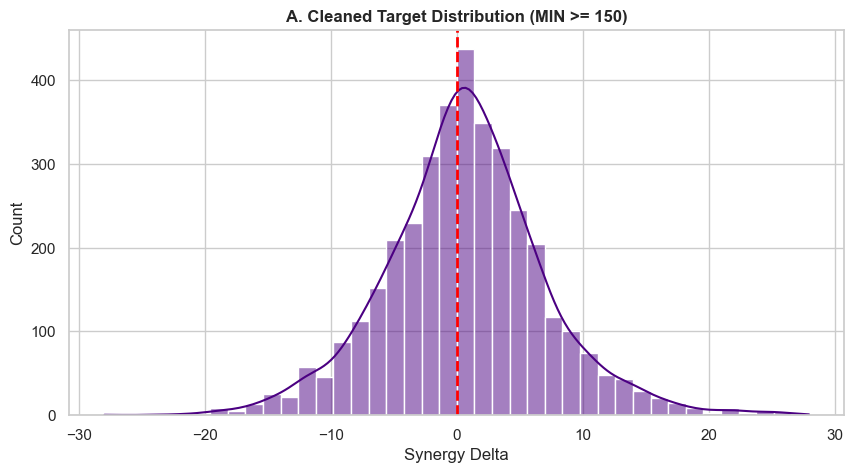

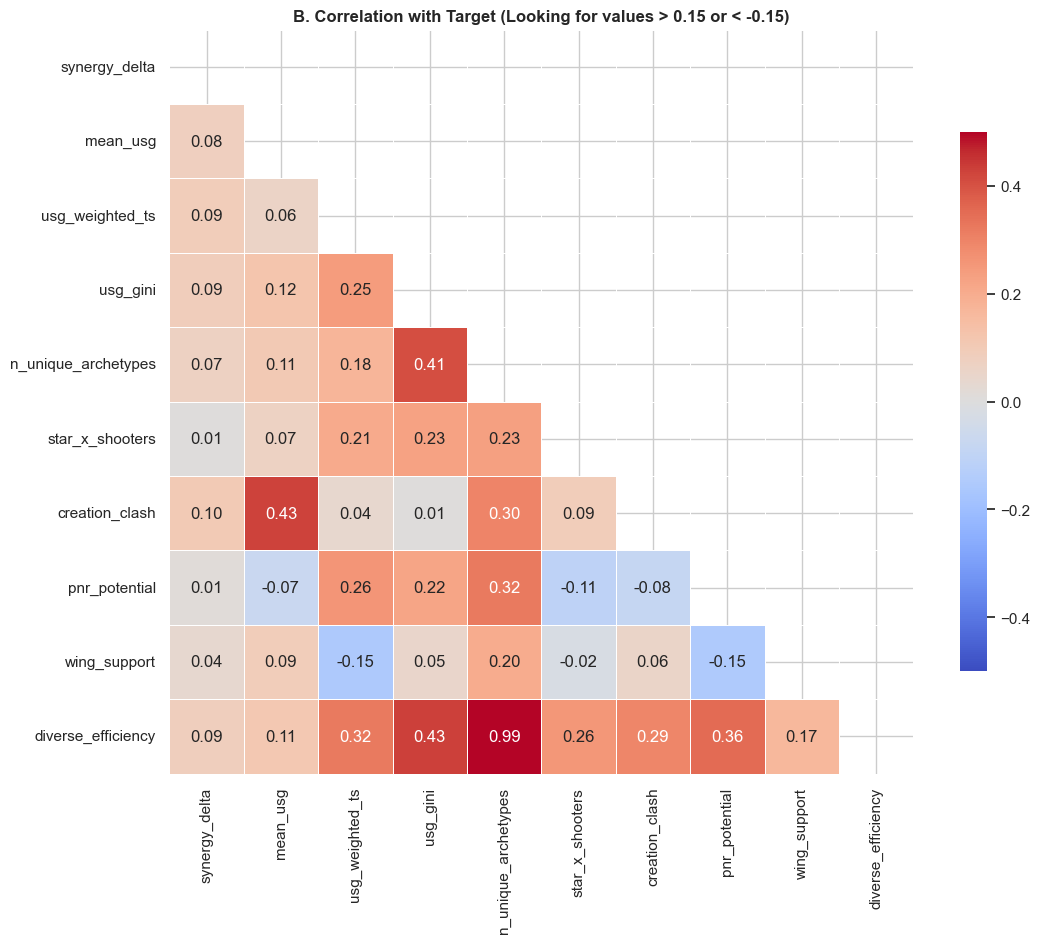

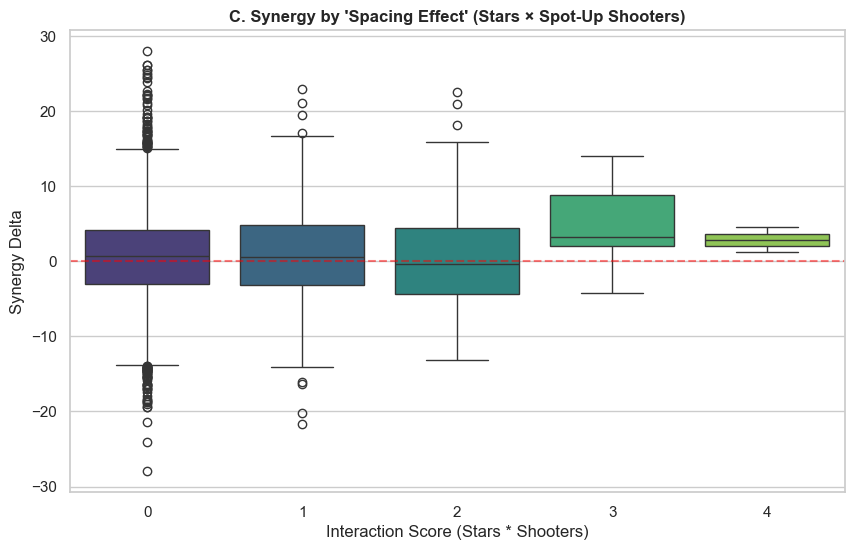

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def engineer_and_test_features(df):
    print("1. Filtering out the noise...")
    # Increase the threshold to 150 minutes (approx. 50 games playing 3 mins together)
    # You can tweak this between 100 and 200 depending on how much data remains
    df_clean = df[df['MIN'].astype(float) >= 150].copy()
    print(f"   Rows remaining after 150-minute filter: {len(df_clean)} (down from {len(df)})")

    print("\n2. Engineering Interaction Features...")
    
    # Ensure columns are numeric first
    numeric_cols = ['n_star_engines', 'n_spotup_shooters', 'n_ball_handlers', 
                    'n_rim_runners', 'n_3andD_wings', 'mean_usg', 'usg_weighted_ts', 
                    'max_ast_pct', 'n_unique_archetypes']
    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

    # FEATURE 1: The Spacing Effect (Stars surrounded by shooters)
    df_clean['star_x_shooters'] = df_clean['n_star_engines'] * df_clean['n_spotup_shooters']
    
    # FEATURE 2: Role Clash / "Too Many Cooks" (Diminishing returns of ball dominance)
    df_clean['creation_clash'] = df_clean['n_star_engines'] * df_clean['n_ball_handlers']
    
    # FEATURE 3: Pick & Roll Potential (Best playmaker + Lob threats)
    df_clean['pnr_potential'] = df_clean['max_ast_pct'] * df_clean['n_rim_runners']
    
    # FEATURE 4: 3-and-D Support (Stars shielded by versatile defenders)
    df_clean['wing_support'] = df_clean['n_star_engines'] * df_clean['n_3andD_wings']
    
    # FEATURE 5: Synergy of Roles (Are they diverse AND efficient?)
    df_clean['diverse_efficiency'] = df_clean['n_unique_archetypes'] * df_clean['usg_weighted_ts']

    print("\n3. Running Updated EDA...")
    sns.set_theme(style="whitegrid")
    
    # Plot A: The New Target Distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean['synergy_delta'], bins=40, kde=True, color='indigo')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.title("A. Cleaned Target Distribution (MIN >= 150)", fontweight='bold')
    plt.xlabel("Synergy Delta")
    plt.show()

    # Plot B: The Updated Correlation Heatmap
    plt.figure(figsize=(12, 10))
    # Mix of old base features and our new interaction features
    check_cols = ['synergy_delta', 'mean_usg', 'usg_weighted_ts', 'usg_gini', 
                  'n_unique_archetypes', 'star_x_shooters', 'creation_clash', 
                  'pnr_potential', 'wing_support', 'diverse_efficiency']
    
    corr = df_clean[check_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.5, vmax=0.5, 
                square=True, linewidths=.5, cbar_kws={"shrink": .7})
    plt.title("B. Correlation with Target (Looking for values > 0.15 or < -0.15)", fontweight='bold')
    plt.show()

    # Plot C: Does Spacing Actually Matter?
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='star_x_shooters', y='synergy_delta', data=df_clean, palette='viridis')
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.title("C. Synergy by 'Spacing Effect' (Stars × Spot-Up Shooters)", fontweight='bold')
    plt.xlabel("Interaction Score (Stars * Shooters)")
    plt.ylabel("Synergy Delta")
    plt.show()

    return df_clean

# Run it!
df_ready_for_training = engineer_and_test_features(df_features)

In [19]:
# Filtering for rows where GROUP_NAME contains 'L. Ball'
filtered_df = df_features[df_features['GROUP_NAME'].str.contains('L. Ball', na=False, regex=False)]

In [22]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

In [32]:
# 1. Define the updated feature list including our new interactions
UPDATED_FEATURES = [
    'n_ball_handlers', 'n_rim_runners', 'n_star_engines',
    'n_3andD_wings', 'n_athletic_role', 'n_spotup_shooters',
    'n_unique_archetypes', 'has_star_engine', 'has_rim_runner',
    'has_ball_handler', 'multiple_ball_handlers', 'multiple_rim_runners',
    'group_size', 'mean_usg', 'std_usg', 'mean_ast_pct', 'max_ast_pct',      
    'mean_ts', 'usg_weighted_ts', 'mean_oreb', 'mean_dreb',        
    'usg_gini', 'star_x_shooters', 'creation_clash', 
    'pnr_potential', 'wing_support', 'diverse_efficiency'
]

# 2. Re-train the model using the clean DataFrame
print("\n--- Retraining with Cleaned Data & Interaction Features ---")
# df_ready_for_training is the output from our EDA function
X = df_ready_for_training[UPDATED_FEATURES].fillna(0)
y = df_ready_for_training['synergy_delta'].astype(float)

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

print("\n--- Running Grid Search to Fix Overfitting ---")

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [150, 250, 350],
    'max_depth': [2, 3],               
    'learning_rate': [0.01, 0.03],     
    'min_samples_leaf': [30, 50, 75],  
    'subsample': [0.6, 0.75]           
}

# Base model
base_model = GradientBoostingRegressor(random_state=42)

# Set up Cross-Validation strategy
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Initialize and run Grid Search
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,                         
    verbose=1
)

print("Searching for the best hyperparameters... (This might take a minute)")
grid_search.fit(X, y)

# 3. Extract the best model
best_model = grid_search.best_estimator_

print("\n--- Tuning Complete! ---")
print("Best Parameters Found:")
for key, value in grid_search.best_params_.items():
    print(f"  {key}: {value}")

# 4. Evaluate the New Best Model
cv_mae_scores = cross_val_score(best_model, X, y, cv=cv_strategy, scoring='neg_mean_absolute_error')
cv_r2_scores  = cross_val_score(best_model, X, y, cv=cv_strategy, scoring='r2')

print("\n--- New Model Performance ---")
print(f"  Cross-validation MAE: {(-cv_mae_scores.mean()):.3f} ± {cv_mae_scores.std():.3f}")
print(f"  Cross-validation R²:  {cv_r2_scores.mean():.3f} ± {cv_r2_scores.std():.3f}")

# Check the new Train vs CV gap
y_pred_train = best_model.predict(X)
print(f"  Train R²:             {r2_score(y, y_pred_train):.3f}")

# 5. Save this specific model for your predictions later
# model = best_model  # Update your main model variable

# 6. Visualize the most important features for the Tuned Model
print("\n--- Generating Feature Importance ---")
# Print the top 10 directly to the console for quick reading
import pandas as pd
importance = pd.Series(best_model.feature_importances_, index=UPDATED_FEATURES)
print(importance.sort_values(ascending=False).head(10).round(4).to_string())

# Generate and save the bar chart using your existing plotting function
plot_feature_importance(best_model, UPDATED_FEATURES)


--- Retraining with Cleaned Data & Interaction Features ---

--- Running Grid Search to Fix Overfitting ---
Searching for the best hyperparameters... (This might take a minute)
Fitting 5 folds for each of 72 candidates, totalling 360 fits



--- Tuning Complete! ---
Best Parameters Found:
  learning_rate: 0.03
  max_depth: 3
  min_samples_leaf: 30
  n_estimators: 350
  subsample: 0.75

--- New Model Performance ---
  Cross-validation MAE: 4.698 ± 0.093
  Cross-validation R²:  0.044 ± 0.013
  Train R²:             0.200

--- Generating Feature Importance ---
max_ast_pct           0.1535
usg_weighted_ts       0.0893
mean_usg              0.0877
std_usg               0.0852
mean_ts               0.0790
mean_dreb             0.0784
mean_oreb             0.0742
usg_gini              0.0655
diverse_efficiency    0.0636
mean_ast_pct          0.0575
  Saved feature_importance.png

── Top 10 most important features ──────────────────────────────────
max_ast_pct           0.1535
usg_weighted_ts       0.0893
mean_usg              0.0877
std_usg               0.0852
mean_ts               0.0790
mean_dreb             0.0784
mean_oreb             0.0742
usg_gini              0.0655
diverse_efficiency    0.0636
mean_ast_pct          0.0

In [60]:
import pandas as pd
from collections import Counter

def predict_dream_team(player_names, model, player_lookup, archetype_lookup, name_to_id, feature_names):
    """
    Takes a list of player names, engineers the exact same features used in training 
    (including the new interaction features!), and returns the model's chemistry prediction.
    """
    # 1. Map names to IDs safely
    player_ids = []
    missing = []
    for name in player_names:
        pid = name_to_id.get(name)
        if pid:
            player_ids.append(pid)
        else:
            missing.append(name)
            
    if missing:
        return f"Error: Could not find these players in your data: {missing}"
    
    group_size = len(player_ids)
    
    # 2. Get individual stats
    rows = [player_lookup.get(pid) for pid in player_ids]
    if any(r is None for r in rows):
        return "Error: Missing stat data for some players."

    def safe_get(row, key):
        val = row.get(key, np.nan)
        return 0.0 if pd.isna(val) else float(val)

    # 3. Calculate Group Averages & Totals (Base Features)
    usg  = [safe_get(r, 'USG_PCT')    for r in rows]
    ast  = [safe_get(r, 'AST_PCT')    for r in rows]
    ts   = [safe_get(r, 'TS_PCT')     for r in rows]
    oreb = [safe_get(r, 'OREB_PCT')   for r in rows]
    dreb = [safe_get(r, 'DREB_PCT')   for r in rows]
    pace = [safe_get(r, 'PACE')       for r in rows]
    
    total_usg = sum(usg)
    usg_weighted_ts = sum(t * u for t, u in zip(ts, usg)) / total_usg if total_usg > 0 else np.mean(ts)
    
    def calculate_gini(values):
        values = np.array(sorted(values))
        n = len(values)
        if n == 0 or values.sum() == 0: return 0.0
        return (2 * np.sum((np.arange(1, n+1)) * values) - (n + 1) * values.sum()) / (n * values.sum())

    # 4. Count Archetypes
    archetypes = [archetype_lookup.get(pid) for pid in player_ids]
    archetypes = [a for a in archetypes if a is not None]
    counts = Counter(archetypes)
    
    n_ball_handlers   = counts.get(0, 0)
    n_rim_runners     = counts.get(1, 0)
    n_star_engines    = counts.get(2, 0)
    n_3andD_wings     = counts.get(3, 0)
    n_athletic_role   = counts.get(4, 0)
    n_spotup_shooters = counts.get(5, 0)
    n_unique          = len(set(archetypes))

    # 5. Build the complete feature dictionary (matching UPDATED_FEATURES exactly)
    feats = {
        'n_ball_handlers':        n_ball_handlers,
        'n_rim_runners':          n_rim_runners,
        'n_star_engines':         n_star_engines,
        'n_3andD_wings':          n_3andD_wings,
        'n_athletic_role':        n_athletic_role,
        'n_spotup_shooters':      n_spotup_shooters,
        'n_unique_archetypes':    n_unique,
        'has_star_engine':        int(n_star_engines > 0),
        'has_rim_runner':         int(n_rim_runners > 0),
        'has_ball_handler':       int(n_ball_handlers > 0),
        'multiple_ball_handlers': int(n_ball_handlers > 1),
        'multiple_rim_runners':   int(n_rim_runners > 1),
        'group_size':             group_size,
        'mean_usg':               np.mean(usg),
        'std_usg':                np.std(usg),
        'mean_ast_pct':           np.mean(ast),
        'max_ast_pct':            np.max(ast),
        'mean_ts':                np.mean(ts),
        'usg_weighted_ts':        usg_weighted_ts,
        'mean_oreb':              np.mean(oreb),
        'mean_dreb':              np.mean(dreb),
        'usg_gini':               calculate_gini(usg),
        
        # --- THE NEW INTERACTION FEATURES ---
        'star_x_shooters':        n_star_engines * n_spotup_shooters,
        'creation_clash':         n_star_engines * n_ball_handlers,
        'pnr_potential':          np.max(ast) * n_rim_runners,
        'wing_support':           n_star_engines * n_3andD_wings,
        'diverse_efficiency':     n_unique * usg_weighted_ts
    }

    # 6. Calculate Baseline Expected Net Rating
    net_ratings = [player_lookup[pid].get('NET_RATING', 0) for pid in player_ids]
    minutes     = [player_lookup[pid].get('MIN', 1) for pid in player_ids]
    expected_net = sum(r * m for r, m in zip(net_ratings, minutes)) / sum(minutes)

    # 7. Predict using the trained model
    X_pred = pd.DataFrame([{f: feats.get(f, 0) for f in feature_names}])
    synergy_delta = model.predict(X_pred)[0]
    
    # Print beautiful output
    print(f"\n🏀 LINEUP: {', '.join(player_names)}")
    print("-" * 50)
    print(f"  Archetype Count:    {n_unique} unique roles")
    print(f"  Baseline Talent:    {expected_net:+.2f} Expected Net Rating")
    print(f"  Chemistry Score:    {synergy_delta:+.2f} (Synergy Delta)")
    print(f"  FINAL NET RATING:   {expected_net + synergy_delta:+.2f}")
    
    if synergy_delta > 2:
        print("  💡 Verdict: Great fit! The whole is greater than the sum of its parts.")
    elif synergy_delta < -2:
        print("  ⚠️ Verdict: Clunky fit. Too much role overlap or poor spacing.")
    else:
        print("  ⚖️ Verdict: Neutral chemistry. They will play exactly to their talent level.")
        
    return synergy_delta

# =====================================================================
# RUN YOUR TEST CASES HERE
# =====================================================================

print("Running Lineup Predictions...")

# Test 1: High Synergy Potential (Elite Playmaker + Shooters + Rim Runner)
lineup_1 = ["Shai Gilgeous-Alexander", "Derrick White", "Jalen Williams", "OG Anunoby", "Chet Holmgren"]

# Test 2: "Too Many Cooks" (Incredible talent, terrible fit - ball dominance clash)
lineup_2 = ["Clint Capela", "Rudy Gobert", "Walker Kessler", "Mitchell Robinson", "Mark Williams"]

# Make sure to pass `UPDATED_FEATURES` (from your training block) or `feature_names` 
# and `best_model` (from the Grid Search)
predict_dream_team(lineup_1, best_model, player_lookup, archetype_lookup, name_to_id, UPDATED_FEATURES)
predict_dream_team(lineup_2, best_model, player_lookup, archetype_lookup, name_to_id, UPDATED_FEATURES)

Running Lineup Predictions...

🏀 LINEUP: Shai Gilgeous-Alexander, Derrick White, Jalen Williams, OG Anunoby, Chet Holmgren
--------------------------------------------------
  Archetype Count:    3 unique roles
  Baseline Talent:    +11.67 Expected Net Rating
  Chemistry Score:    +1.57 (Synergy Delta)
  FINAL NET RATING:   +13.25
  ⚖️ Verdict: Neutral chemistry. They will play exactly to their talent level.

🏀 LINEUP: Clint Capela, Rudy Gobert, Walker Kessler, Mitchell Robinson, Mark Williams
--------------------------------------------------
  Archetype Count:    1 unique roles
  Baseline Talent:    +4.80 Expected Net Rating
  Chemistry Score:    +2.79 (Synergy Delta)
  FINAL NET RATING:   +7.60
  💡 Verdict: Great fit! The whole is greater than the sum of its parts.


np.float64(2.793682737745655)

In [62]:
players

,PLAYER_ID,PLAYER_NAME,NET_RATING,OFF_RATING,DEF_RATING,PIE,TS_PCT,USG_PCT,AST_PCT,OREB_PCT,DREB_PCT,REB_PCT,MIN,GP,season,cluster
0,1630639,A.J. Lawson,-14.2,100.9,115.1,0.079,0.545,0.185,0.045,0.055,0.160,0.101,7.9,14,2025-26,NaN
1,1631260,AJ Green,-1.6,113.2,114.9,0.052,0.610,0.129,0.085,0.009,0.072,0.041,29.7,59,2025-26,5.0
2,1642358,AJ Johnson,-4.8,102.6,107.4,0.044,0.397,0.189,0.147,0.025,0.103,0.062,9.0,36,2025-26,3.0
3,203932,Aaron Gordon,13.1,122.8,109.7,0.134,0.622,0.226,0.131,0.049,0.161,0.107,27.6,24,2025-26,2.0
4,1628988,Aaron Holiday,4.6,112.5,107.8,0.061,0.566,0.171,0.098,0.011,0.054,0.033,13.1,41,2025-26,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,1641744,Zach Edey,18.3,112.8,94.5,0.157,0.669,0.200,0.061,0.148,0.243,0.198,25.8,11,2025-26,NaN
545,203897,Zach LaVine,-12.6,109.3,121.9,0.096,0.614,0.234,0.111,0.006,0.083,0.044,31.4,39,2025-26,0.0
546,1630192,Zeke Nnaji,-7.3,107.0,114.3,0.074,0.573,0.137,0.065,0.054,0.151,0.105,12.5,45,2025-26,4.0
547,1630533,Ziaire Williams,-9.5,104.8,114.3,0.072,0.578,0.169,0.065,0.023,0.084,0.053,23.0,45,2025-26,5.0


In [67]:
import itertools
import pandas as pd
import numpy as np
from collections import Counter

# Archetype labels for readable output
ARCHETYPE_LABELS = {
    0: "Primary Ball-Handler",
    1: "Rim-Runner",
    2: "Star Versatile Engine",
    3: "3-and-D Wing",
    4: "Athletic Role Player",
    5: "Spot-Up Shooter",
}

def predict_lineup_silent(player_ids, model, player_lookup, archetype_lookup, feature_names):
    """Silent predictor for batch processing, returning archetype names."""
    rows = [player_lookup.get(pid) for pid in player_ids if pid in player_lookup]
    if len(rows) != len(player_ids) or len(rows) == 0:
        return None
        
    group_size = len(player_ids)
    
    usg = [float(r.get('USG_PCT', 0)) for r in rows]
    ast = [float(r.get('AST_PCT', 0)) for r in rows]
    ts = [float(r.get('TS_PCT', 0)) for r in rows]
    oreb = [float(r.get('OREB_PCT', 0)) for r in rows]
    dreb = [float(r.get('DREB_PCT', 0)) for r in rows]
    
    total_usg = sum(usg)
    usg_weighted_ts = sum(t * u for t, u in zip(ts, usg)) / total_usg if total_usg > 0 else np.mean(ts)
    
    usg_sorted = np.array(sorted(usg))
    n = len(usg_sorted)
    usg_gini = 0.0
    if n > 0 and usg_sorted.sum() > 0:
        usg_gini = (2 * np.sum((np.arange(1, n+1)) * usg_sorted) - (n + 1) * usg_sorted.sum()) / (n * usg_sorted.sum())

    archetypes = [archetype_lookup.get(pid) for pid in player_ids if pid in archetype_lookup]
    counts = Counter(archetypes)
    n_unique = len(set(archetypes))

    feats = {
        'n_ball_handlers': counts.get(0, 0), 'n_rim_runners': counts.get(1, 0),
        'n_star_engines': counts.get(2, 0), 'n_3andD_wings': counts.get(3, 0),
        'n_athletic_role': counts.get(4, 0), 'n_spotup_shooters': counts.get(5, 0),
        'n_unique_archetypes': n_unique,
        'has_star_engine': int(counts.get(2, 0) > 0), 'has_rim_runner': int(counts.get(1, 0) > 0),
        'has_ball_handler': int(counts.get(0, 0) > 0),
        'multiple_ball_handlers': int(counts.get(0, 0) > 1), 'multiple_rim_runners': int(counts.get(1, 0) > 1),
        'group_size': group_size, 'mean_usg': np.mean(usg), 'std_usg': np.std(usg),
        'mean_ast_pct': np.mean(ast), 'max_ast_pct': np.max(ast), 'mean_ts': np.mean(ts),
        'usg_weighted_ts': usg_weighted_ts, 'mean_oreb': np.mean(oreb), 'mean_dreb': np.mean(dreb),
        'usg_gini': usg_gini, 'star_x_shooters': counts.get(2, 0) * counts.get(5, 0),
        'creation_clash': counts.get(2, 0) * counts.get(0, 0), 'pnr_potential': np.max(ast) * counts.get(1, 0),
        'wing_support': counts.get(2, 0) * counts.get(3, 0), 'diverse_efficiency': n_unique * usg_weighted_ts
    }

    net_ratings = [float(r.get('NET_RATING', 0)) for r in rows]
    minutes = [float(r.get('MIN', 1)) for r in rows]
    expected_net = sum(r * m for r, m in zip(net_ratings, minutes)) / sum(minutes)

    X_pred = pd.DataFrame([{f: feats.get(f, 0) for f in feature_names}])
    synergy_delta = model.predict(X_pred)[0]
    
    archetype_names = [ARCHETYPE_LABELS.get(a, "Unknown") for a in archetypes]
    
    return {
        'Baseline_Net': round(expected_net, 2),
        'Synergy': round(synergy_delta, 2),
        'Predicted_Net': round(expected_net + synergy_delta, 2),
        'Archetypes': " | ".join(sorted(archetype_names))
    }

def find_best_and_worst_combinations(players_df, model, player_lookup, archetype_lookup, feature_names, top_n=35):
    print(f"Creating an All-Star pool of the Top {top_n} players by minutes played...")
    players_df['MIN'] = pd.to_numeric(players_df['MIN'], errors='coerce')
    elite_pool = players_df.sort_values(by='MIN', ascending=False).head(top_n)
    
    id_to_name = dict(zip(elite_pool['PLAYER_ID'].astype(str), elite_pool['PLAYER_NAME']))
    player_ids = list(id_to_name.keys())
    
    best_results = {2: [], 3: [], 4: [], 5: []}
    worst_results = {2: [], 3: [], 4: [], 5: []}
    
    for size in [2, 3, 4, 5]:
        print(f"Calculating all {size}-man combinations...")
        combos = list(itertools.combinations(player_ids, size))
        
        size_results = []
        for combo in combos:
            res = predict_lineup_silent(combo, model, player_lookup, archetype_lookup, feature_names)
            if res:
                names = [id_to_name[pid] for pid in combo]
                size_results.append({
                    'Lineup': ", ".join(names),
                    'Predicted_Net': res['Predicted_Net'],
                    'Synergy': res['Synergy'],
                    'Baseline_Net': res['Baseline_Net'],
                    'Archetypes': res['Archetypes']
                })
        
        # Sort by Predicted_Net 
        size_df = pd.DataFrame(size_results).sort_values(by='Predicted_Net', ascending=False)
        
        # Save Top 3 Best and Top 3 Worst (Reversed so worst is at the top)
        best_results[size] = size_df.head(3)
        worst_results[size] = size_df.tail(3).sort_values(by='Predicted_Net', ascending=True)
        
    return best_results, worst_results

# =====================================================================
# RUN THE GENERATOR
# =====================================================================

best_combos, worst_combos = find_best_and_worst_combinations(players, best_model, player_lookup, archetype_lookup, UPDATED_FEATURES, top_n=35)

print("\n" + "="*80)
print("🏆 THE BEST LINEUP COMBINATIONS 🏆")
print("="*80)
for size in [2, 3, 4, 5]:
    print(f"\n🔥 TOP 3 {size}-MAN LINEUPS 🔥")
    for index, row in best_combos[size].iterrows():
        print(f"  Lineup:     {row['Lineup']}")
        print(f"  Rating:     {row['Predicted_Net']:+.2f}  (Base: {row['Baseline_Net']:+.2f} | Synergy: {row['Synergy']:+.2f})")
        print(f"  Archetypes: {row['Archetypes']}\n")

print("\n" + "="*80)
print("🚨 THE WORST LINEUP COMBINATIONS 🚨")
print("="*80)
for size in [2, 3, 4, 5]:
    print(f"\n🧊 BOTTOM 3 {size}-MAN LINEUPS 🧊")
    for index, row in worst_combos[size].iterrows():
        print(f"  Lineup:     {row['Lineup']}")
        print(f"  Rating:     {row['Predicted_Net']:+.2f}  (Base: {row['Baseline_Net']:+.2f} | Synergy: {row['Synergy']:+.2f})")
        print(f"  Archetypes: {row['Archetypes']}\n")

Creating an All-Star pool of the Top 35 players by minutes played...
Calculating all 2-man combinations...
Calculating all 3-man combinations...
Calculating all 4-man combinations...
Calculating all 5-man combinations...

🏆 THE BEST LINEUP COMBINATIONS 🏆

🔥 TOP 3 2-MAN LINEUPS 🔥
  Lineup:     Nikola Jokić, Shai Gilgeous-Alexander
  Rating:     +16.53  (Base: +12.86 | Synergy: +3.67)
  Archetypes: Primary Ball-Handler | Star Versatile Engine

  Lineup:     Derrick White, Shai Gilgeous-Alexander
  Rating:     +15.73  (Base: +13.53 | Synergy: +2.20)
  Archetypes: Primary Ball-Handler | Primary Ball-Handler

  Lineup:     Donovan Mitchell, Shai Gilgeous-Alexander
  Rating:     +15.03  (Base: +12.05 | Synergy: +2.99)
  Archetypes: Primary Ball-Handler | Primary Ball-Handler


🔥 TOP 3 3-MAN LINEUPS 🔥
  Lineup:     Nikola Jokić, Derrick White, Shai Gilgeous-Alexander
  Rating:     +18.75  (Base: +12.54 | Synergy: +6.21)
  Archetypes: Primary Ball-Handler | Primary Ball-Handler | Star Versatil

### Adjusted model to find best archetypes

In [10]:
from src.model.find_best_archetypes import load_data as load_data_archetypes, build_affinity_dataset, build_affinity_profile, build_best_archetype_summary, q

ImportError: cannot import name 'q' from 'src.model.find_best_archetypes' (/Users/rodrigo/Documents/bench_chemistry/src/model/find_best_archetypes.py)

In [11]:
lineups, players, archetype_lookup, name_lookup, player_stats_lookup = load_data_archetypes()

# Build raw dataset
df_affinity = build_affinity_dataset(lineups, archetype_lookup, name_lookup)
# df_affinity.to_csv('player_affinity_raw.csv', index=False)
# print("  Saved player_affinity_raw.csv")

# Flavor 1
profile = build_affinity_profile(df_affinity)
# profile.to_csv('player_affinity_profile.csv', index=False)
# print("  Saved player_affinity_profile.csv")

summary = build_best_archetype_summary(profile)
# summary.to_csv('player_best_archetype.csv', index=False)
# print("  Saved player_best_archetype.csv")

Loading data...
  7920 lineups  |  549 players

Building player affinity dataset (all group sizes)...
  23969 player x lineup rows
  425 unique players

── Flavor 1: Building affinity profiles ────────────────────────────
  1671 player x archetype pairs with 3+ observations

── Top 10 players by best partner synergy delta ────────────────────
     player_name   own_archetype best_partner  best_partner_delta worst_partner  worst_partner_delta  delta_range
Collin Gillespie    Ball-Handler            ?              20.972    Rim-Runner               -1.329       22.301
 Mohamed Diawara Spot-Up Shooter  Star Engine              17.025    Rim-Runner               -5.260       22.285
  Grant Williams   Athletic Role   Rim-Runner              16.261   Star Engine                6.099       10.162
   Norman Powell    Ball-Handler            ?              15.406  Ball-Handler               -3.473       18.879
      Noah Penda   Athletic Role   Rim-Runner              15.261 Athletic Role      

In [12]:
summary[summary['player_name']=='Shai Gilgeous-Alexander']

,player_id,player_name,own_archetype,best_partner,best_partner_delta,worst_partner,worst_partner_delta,delta_range,archetype_ranking,total_min
56,1628983,Shai Gilgeous-Alexander,Ball-Handler,Star Engine,11.988,Athletic Role,0.912,11.077,"{'Star Engine': 11.988, 'Ball-Handler': 3.406,...",20282


In [13]:
from src.model.find_best_archetypes import add_player_stats_to_affinity, train_affinity_model, predict_all_affinities, plot_affinity_heatmap, plot_top_players_per_archetype, query_player
import pickle

In [14]:
df_enriched = add_player_stats_to_affinity(df_affinity, player_stats_lookup)
model, feature_names = train_affinity_model(df_enriched)

with open('affinity_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': feature_names}, f)
print("  Saved affinity_model.pkl")

predictions = predict_all_affinities(players, model, feature_names, player_stats_lookup)
predictions.to_csv('affinity_predictions.csv', index=False)
print("  Saved affinity_predictions.csv")

# Plots
print("\nGenerating plots...")
plot_affinity_heatmap(predictions)
plot_top_players_per_archetype(predictions)

# Example queries — edit these names to explore any player
for name in ["Jokić", "Gilgeous-Alexander", "Dončić"]:
    query_player(name, summary, predictions)

print("\nDone.")


── Flavor 2: Training affinity prediction model ─────────────────────
  Training on 23969 rows  |  18 features
  CV R²:  0.043 ± 0.006
  CV MAE: 7.919 ± 0.115
  Train R²:  0.070
  Train MAE: 7.812

  Top features:
own_net_rating       0.2436
ts_gap               0.0719
own_usg              0.0716
own_ts               0.0680
own_oreb             0.0651
own_dreb             0.0637
own_ast              0.0614
usg_compatibility    0.0601
  Saved affinity_model.pkl

  Predicting affinities for all player x archetype combinations...
  Saved affinity_predictions.csv

Generating plots...
  Saved affinity_heatmap.png
  Saved top_players_per_archetype.png

  AFFINITY REPORT: JOKIĆ

  [Observed]  Own archetype: Star Engine
  Best partner:  Star Engine  (+8.502)
  Worst partner: Spot-Up Shooter  (+2.584)
  Full ranking:  {'Star Engine': 8.502, '3-and-D Wing': 5.861, 'Ball-Handler': 4.054, 'Spot-Up Shooter': 2.584}

  [Predicted] Archetype affinity ranking:
  Star Engine           +4.906  ████████